## Student Performance Indicator

 Life Cycle of Machine Learning Project

• Understanding the Problem Statement
 • Data Collection
 • Data Checks to Perform
 • Exploratory Data Analysis

 • Data Pre-Processing
• Model Training
 • Choose Best Model

##  1) Problem Statement

1) Problem Statement

• This project understands how the student's performance (test scores) is affected by other variables such as:
  - Gender
  - Ethnicity
  - Parental level of education
  - Lunch
  - Test preparation course


2) Data Collection

• Dataset Source:
  https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

• The dataset consists of:
  - 8 Columns
  - 1000 Rows

In [40]:
import pandas as pd 
import numpy as np 
import seaborn  as sns
import matplotlib.pyplot as plt 


## Import the SCV as pandas DataFram

In [41]:
df = pd.read_csv('data/StudentsPerformance.csv')

In [42]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [43]:
df.shape

(1000, 8)

 ## 2.2 Dataset Information

• gender : sex of students -> (Male/Female)

• race/ethnicity : ethnicity of students -> (Group A, B, C, D, E)

• parental level of education : parents' final education ->
  (bachelor's degree, some college, master's degree,
   associate's degree, high school)

• lunch : having lunch before test
  (standard or free/reduced)

• test preparation course : complete or not complete before test

• math score

• reading score

• writing score

## 3. Data Checks to Perform

• Check Missing Values

• Check Duplicates

• Check Data Types

• Check the Number of Unique Values in Each Column

• Check Statistics of the Dataset

• Check Various Categories Present in the Different Categorical Columns

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [45]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(0)

## Check the numbers of unique values of each columns 

In [47]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [48]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Insight

• From the above description of the numerical data, all means are very close to each other – between 66 and 68.05.

• All standard deviations are also close – between 14.6 and 15.19.

• The minimum score for Math is 0, while the minimum score for Writing is 10, and the minimum score for Reading is 17.

## Exploring data 

In [49]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [50]:
print("Categories in 'gender' variable: ", end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable: ", end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable: ", end=" ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable: ", end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ", end=" ")
print(df['test preparation course'].unique())

Categories in 'gender' variable:  <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' variable:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental level of education' variable:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [51]:
# define numerical & categorical columns

numeric_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

# print columns

print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math score', 'reading score', 'writing score']

We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


## Adding columns for "Total Score" and "Average"

In [52]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score'] / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [53]:
reading_full = df[df['reading score'] == 100]['average'].count()
writing_full = df[df['writing score'] == 100]['average'].count()
math_full = df[df['math score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [54]:
reading_less_20 = df[df['reading score'] <= 20]['average'].count()
writing_less_20 = df[df['writing score'] <= 20]['average'].count()
math_less_20 = df[df['math score'] <= 20]['average'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


# ==========================================================
## 4. Exploring Data (Visualization)
# ==========================================================

# 4.1 Visualize average score distribution to make some conclusion.

# • Histogram
# • Kernel Distribution Function (KDE)

# Histogram and KDE

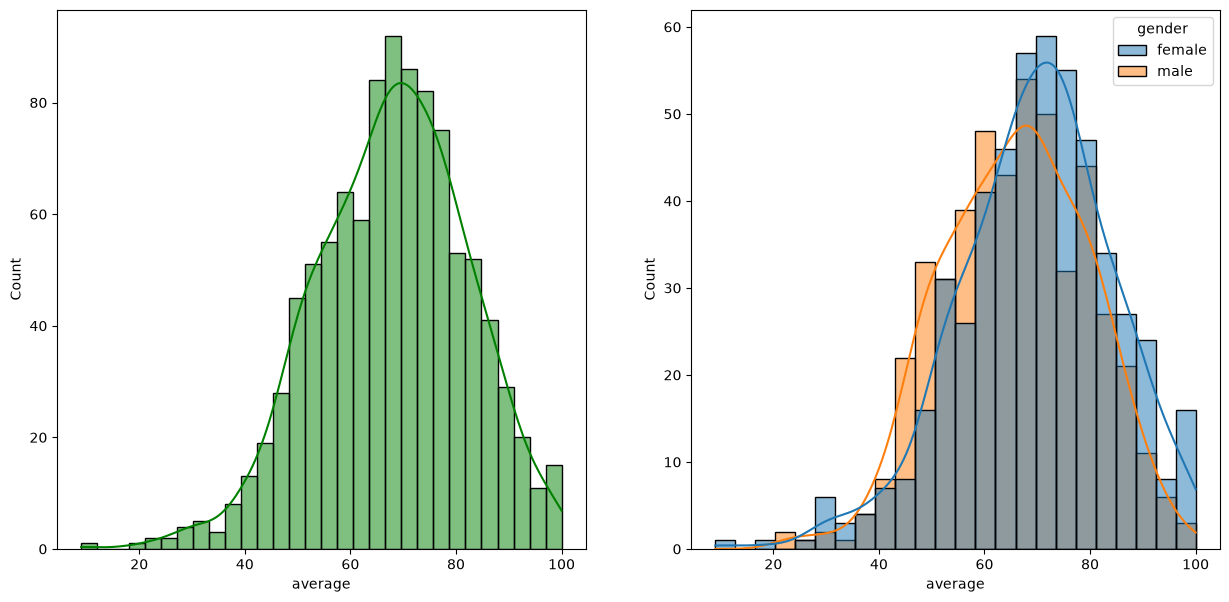

In [55]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

plt.subplot(121)
sns.histplot(data=df, x='average', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=df, x='average', kde=True, hue='gender')

plt.show()

female student perfrom well 

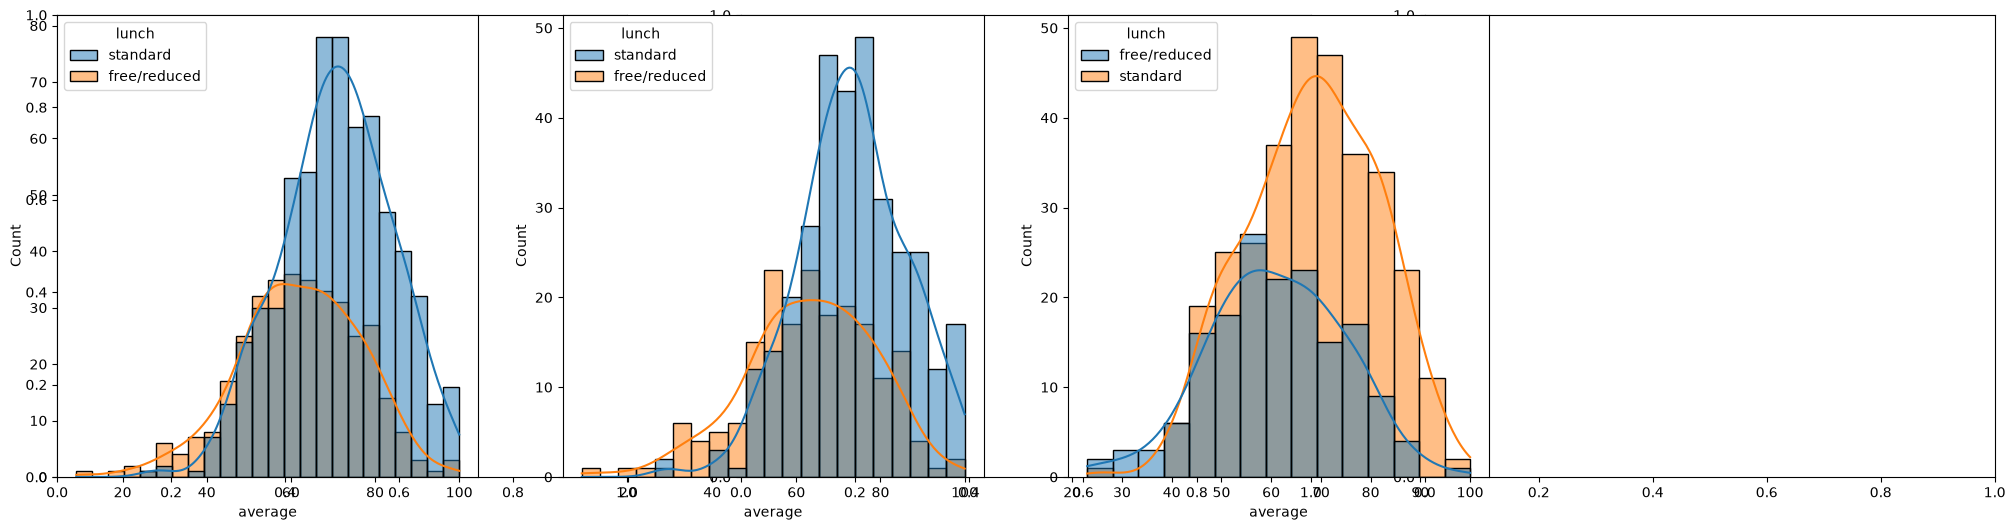

In [56]:
plt.subplots(1, 3, figsize=(25, 6))

plt.subplot(141)
sns.histplot(data=df, x='average', kde=True, hue='lunch')

plt.subplot(142)
sns.histplot(data=df[df.gender == 'female'], x='average', kde=True, hue='lunch')

plt.subplot(143)
sns.histplot(data=df[df.gender == 'male'], x='average', kde=True, hue='lunch')

plt.show()

## insights 
standerd launch helps perfoms well 

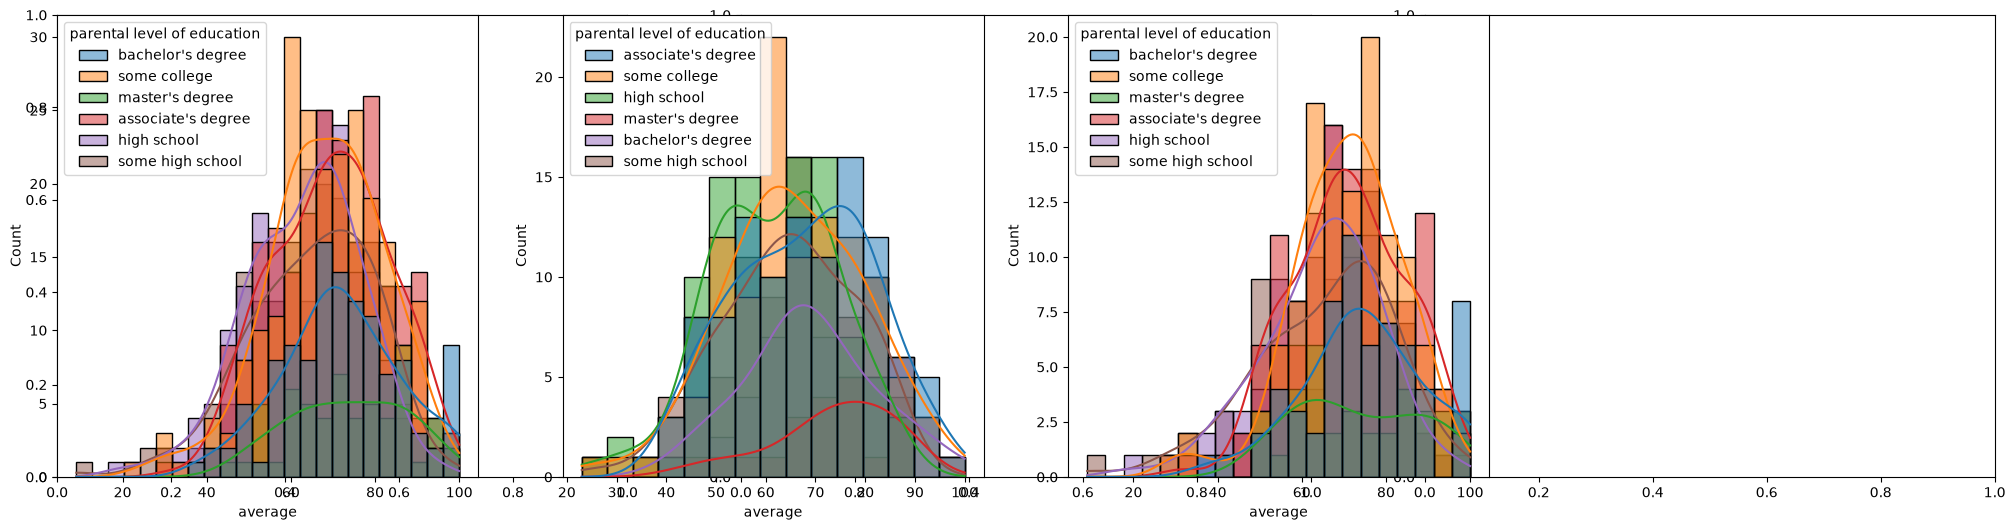

In [60]:
plt.subplots(1, 3, figsize=(25, 6))

plt.subplot(141)
ax = sns.histplot(data=df, x='average', kde=True, hue='parental level of education')

plt.subplot(142)
ax = sns.histplot(data=df[df.gender == 'male'], x='average', kde=True, hue='parental level of education')

plt.subplot(143)
ax = sns.histplot(data=df[df.gender == 'female'], x='average', kde=True, hue='parental level of education')

plt.show()

plt.subplots(1, 3, figsize=(25, 6))

plt.subplot(141)
ax = sns.histplot(
    data=df,
    x='average',
    kde=True,
    hue='parental level of education'
)

plt.subplot(142)
ax = sns.histplot(
    data=df[df.gender == 'male'],
    x='average',
    kde=True,
    hue='parental level of education'
)

plt.subplot(143)
ax = sns.histplot(
    data=df[df.gender == 'female'],
    x='average',
    kde=True,
    hue='parental level of education'
)

plt.show()

## Insights
In general parent's education don't help student perform well in exam.
2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam.
3rd plot we can see there is no effect of parent's education on female students.

# 4.2 Maximum score of students in all three subjects

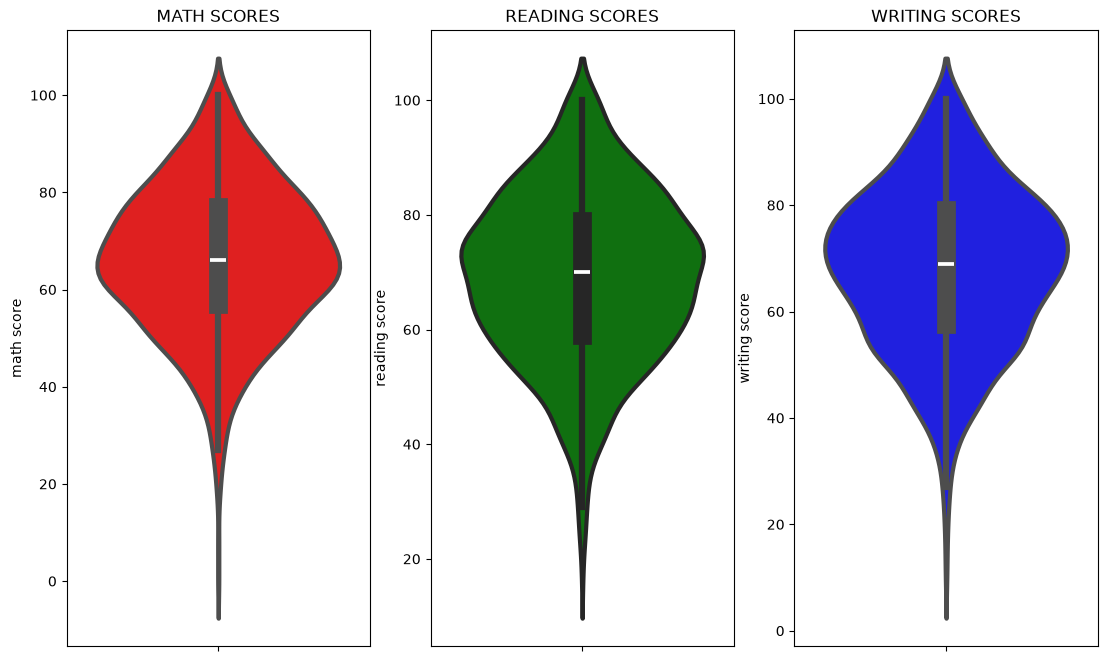

In [62]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math score', data=df, color='red', linewidth=3)

plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading score', data=df, color='green', linewidth=3)

plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score', data=df, color='blue', linewidth=3)

plt.show()

#Insights

From the above three plots its clearly visible that most of the students score in between 60–80 in Maths, whereas in Reading and Writing most of them score from 50–80

# Multivaraitive analysis using pyplot 

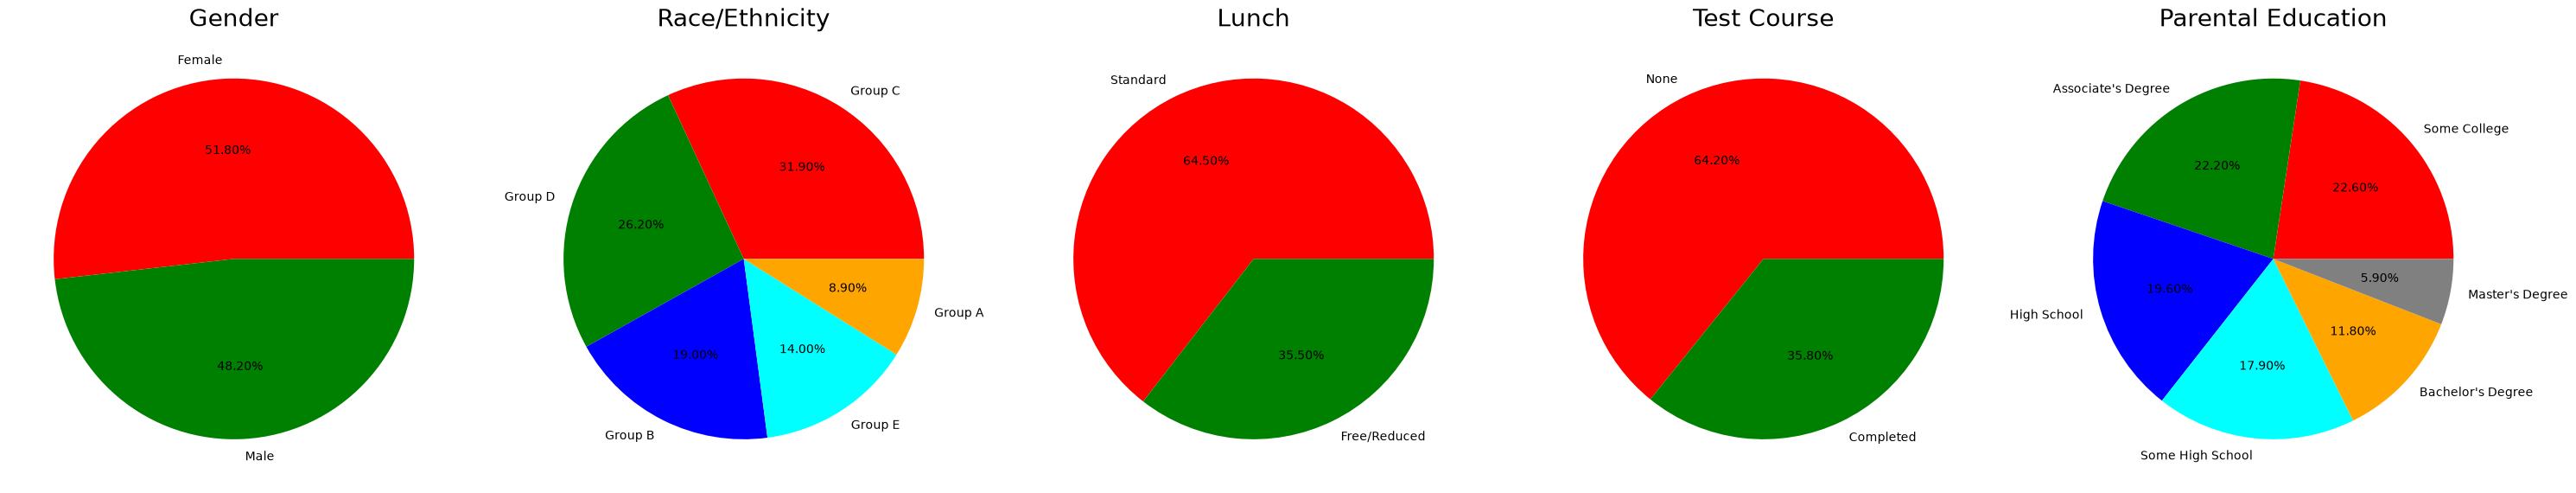

In [65]:
# ==========================================================
# 4.3 Distribution of Categorical Features
# ==========================================================

plt.rcParams['figure.figsize'] = (30, 12)

# ---------------- Gender ----------------
plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = ['Female', 'Male']
color = ['red', 'green']

plt.pie(size, colors=color, labels=labels, autopct='%.2f%%')
plt.title('Gender', fontsize=20)
plt.axis('off')

# ---------------- Race / Ethnicity ----------------
plt.subplot(1, 5, 2)
size = df['race/ethnicity'].value_counts()
labels = ['Group C', 'Group D', 'Group B', 'Group E', 'Group A']
color = ['red', 'green', 'blue', 'cyan', 'orange']

plt.pie(size, colors=color, labels=labels, autopct='%.2f%%')
plt.title('Race/Ethnicity', fontsize=20)
plt.axis('off')

# ---------------- Lunch ----------------
plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = ['Standard', 'Free/Reduced']
color = ['red', 'green']

plt.pie(size, colors=color, labels=labels, autopct='%.2f%%')
plt.title('Lunch', fontsize=20)
plt.axis('off')

# ---------------- Test Preparation Course ----------------
plt.subplot(1, 5, 4)
size = df['test preparation course'].value_counts()
labels = ['None', 'Completed']
color = ['red', 'green']

plt.pie(size, colors=color, labels=labels, autopct='%.2f%%')
plt.title('Test Course', fontsize=20)
plt.axis('off')

# ---------------- Parental Level of Education ----------------
plt.subplot(1, 5, 5)
size = df['parental level of education'].value_counts()
labels = [
    'Some College',
    "Associate's Degree",
    'High School',
    'Some High School',
    "Bachelor's Degree",
    "Master's Degree"
]
color = ['red', 'green', 'blue', 'cyan', 'orange', 'grey']

plt.pie(size, colors=color, labels=labels, autopct='%.2f%%')
plt.title('Parental Education', fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid()

plt.show()

## Insights
Number of Male and Female students is almost equal.
Number of students are greatest in Group C.
Number of students who have Standard Lunch are greater.
Number of students who have not enrolled in any Test Preparation Course is greater.
Number of students whose parental education is "Some College" is greater, followed closely by "Associate's Degree".

## Feature wise visualization 

• How is distribution of Gender?
• Is gender has any impact on student's performance?

# UNIVARIATE ANALYSIS (How is distribution of Gender?)

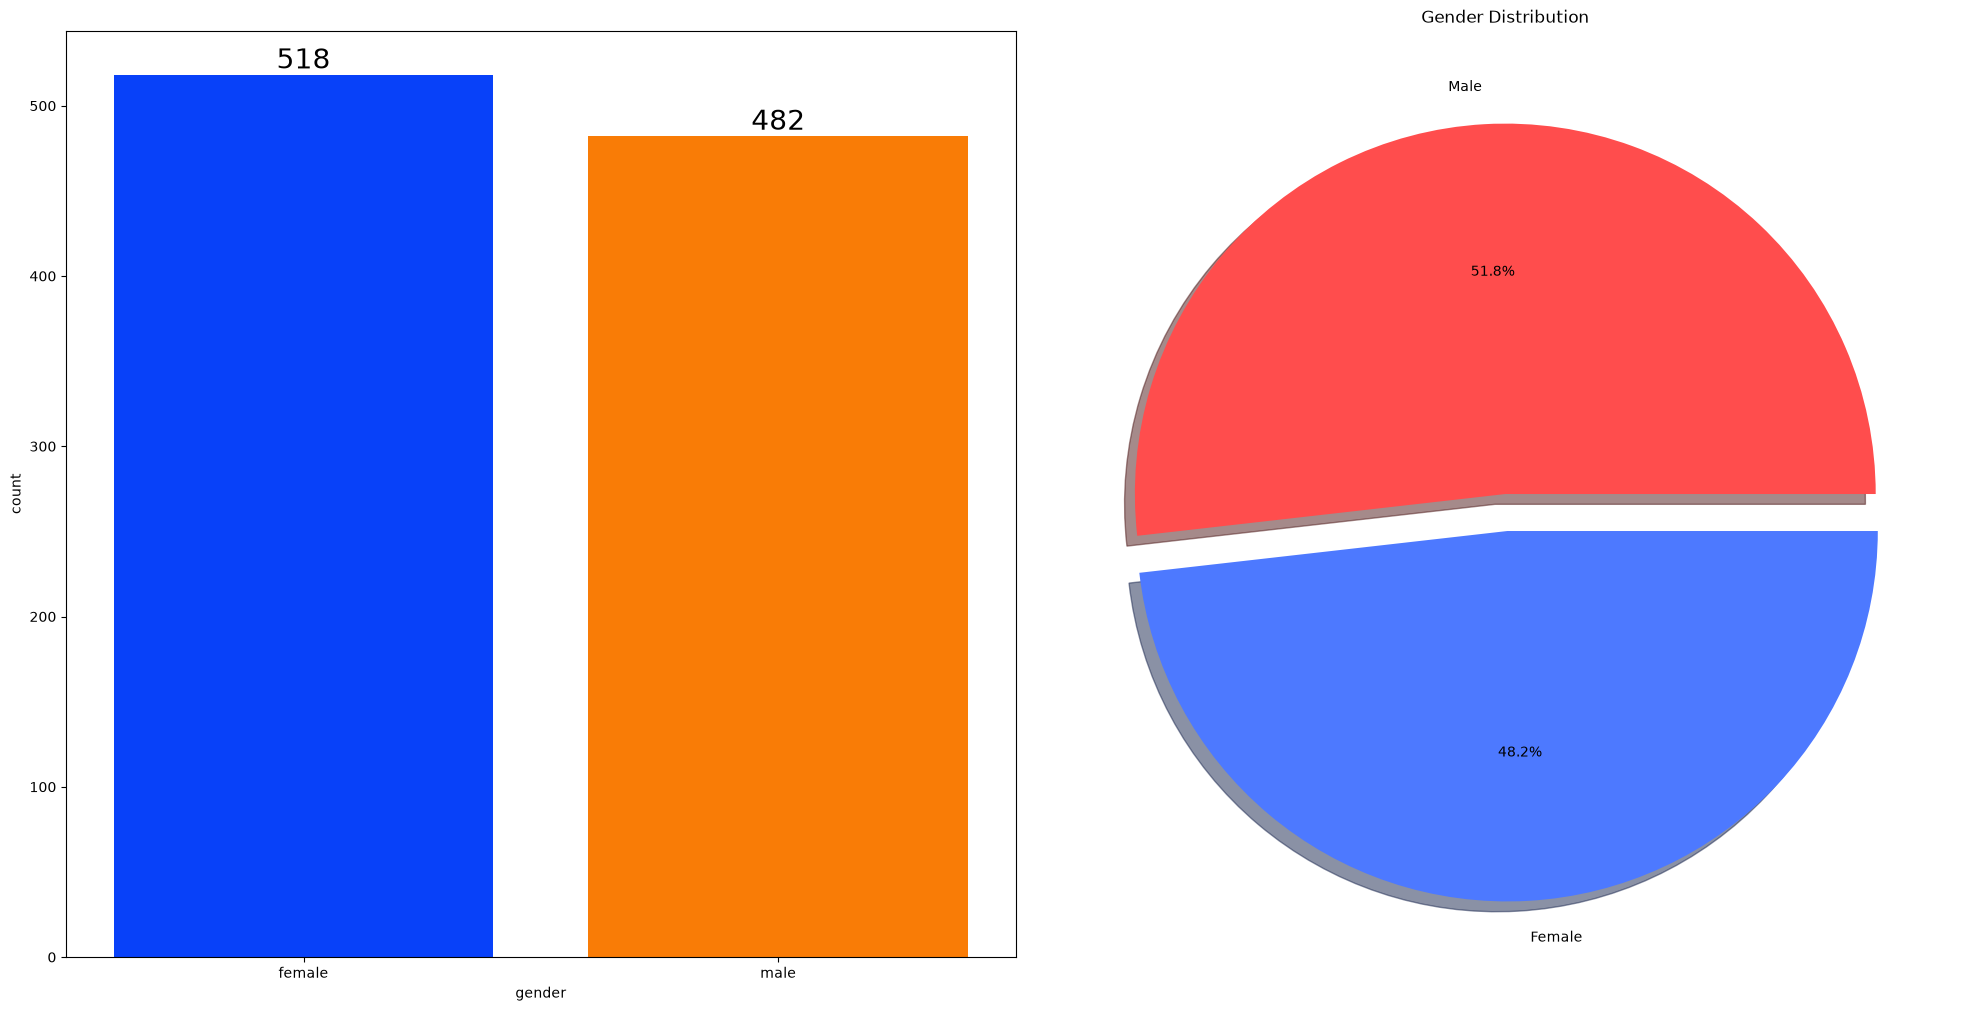

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with 2 subplots
f, ax = plt.subplots(1, 2, figsize=(20, 10))

# Count Plot
sns.countplot(
    data=df,
    x='gender',
    hue='gender',
    palette='bright',
    legend=False,
    ax=ax[0],
    saturation=0.95
)

# Add count labels on bars
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

# Pie Chart
ax[1].pie(
    df['gender'].value_counts(),
    labels=['Male', 'Female'],
    explode=[0, 0.1],
    autopct='%1.1f%%',
    shadow=True,
    colors=['#ff4d4d', '#4d79ff']
)

ax[1].set_title("Gender Distribution")

plt.tight_layout()
plt.show()

## Insights
Gender has balanced data with female students are 518 (48%) and male students are 482 (52%).

## BIVARIATE ANALYSIS

( Is gender has any impact on student's performance ? )

For a more professional EDA notebook, you can write it as:

Insights
The dataset is well balanced in terms of gender distribution, with 518 female students (48%) and 482 male students (52%)

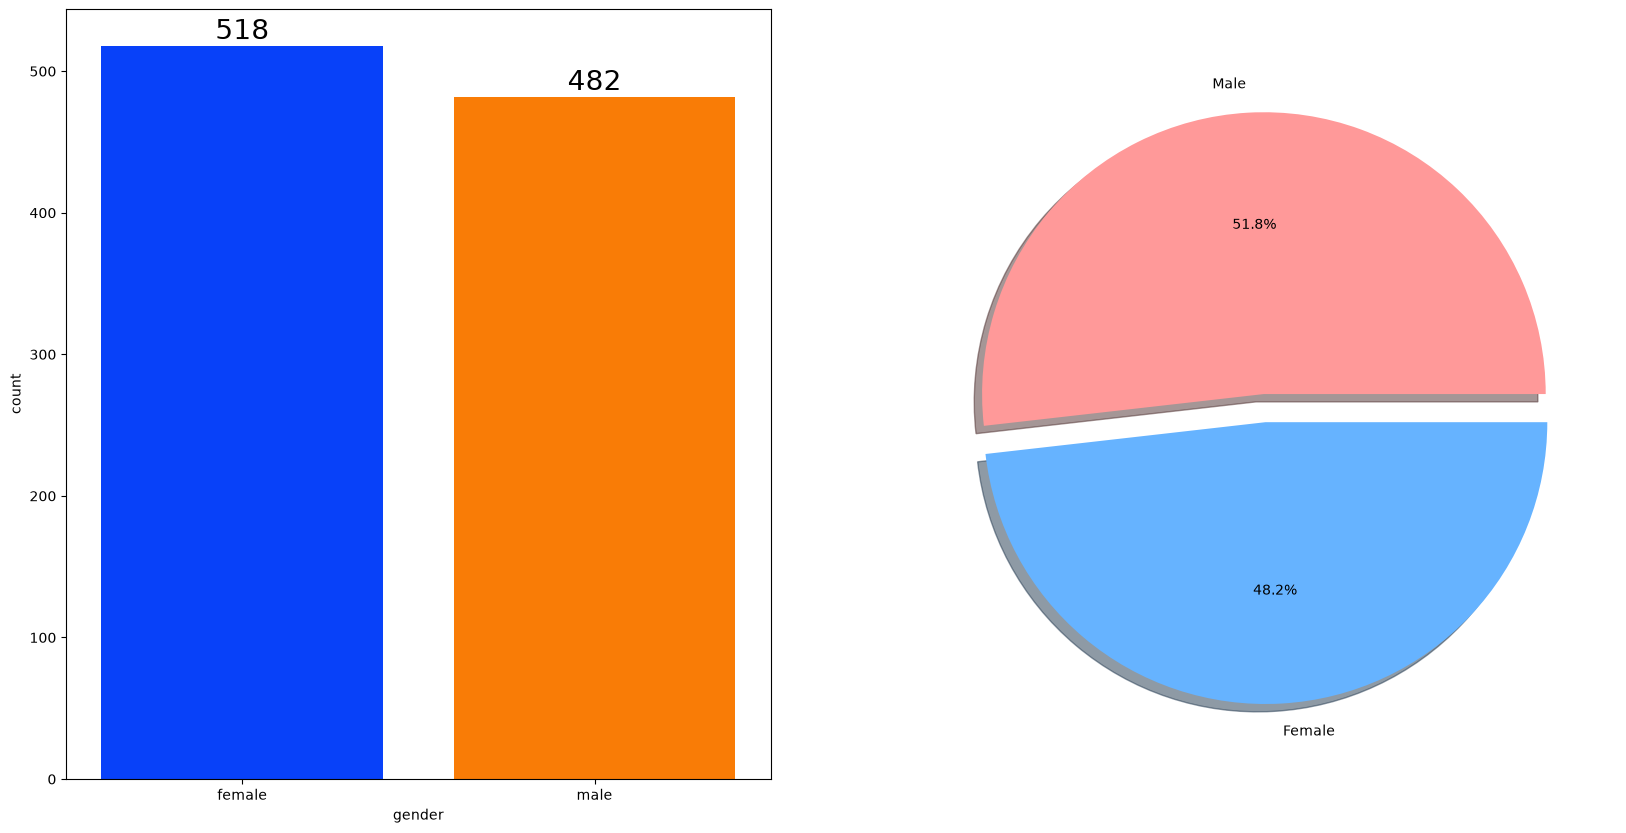

In [69]:
# Create a figure with 1 row and 2 columns
f, ax = plt.subplots(1, 2, figsize=(20, 10))

# Count Plot
sns.countplot(
    x=df['gender'],
    hue='gender',
    data=df,
    palette='bright',
    ax=ax[0],
    saturation=0.95
)

# Add count labels on top of bars
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

# Pie Chart
plt.pie(
    x=df['gender'].value_counts(),
    labels=['Male', 'Female'],
    explode=[0, 0.1],
    autopct='%1.1f%%',
    shadow=True,
    colors=['#ff9999', '#66b3ff']
)

plt.show()

## BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )

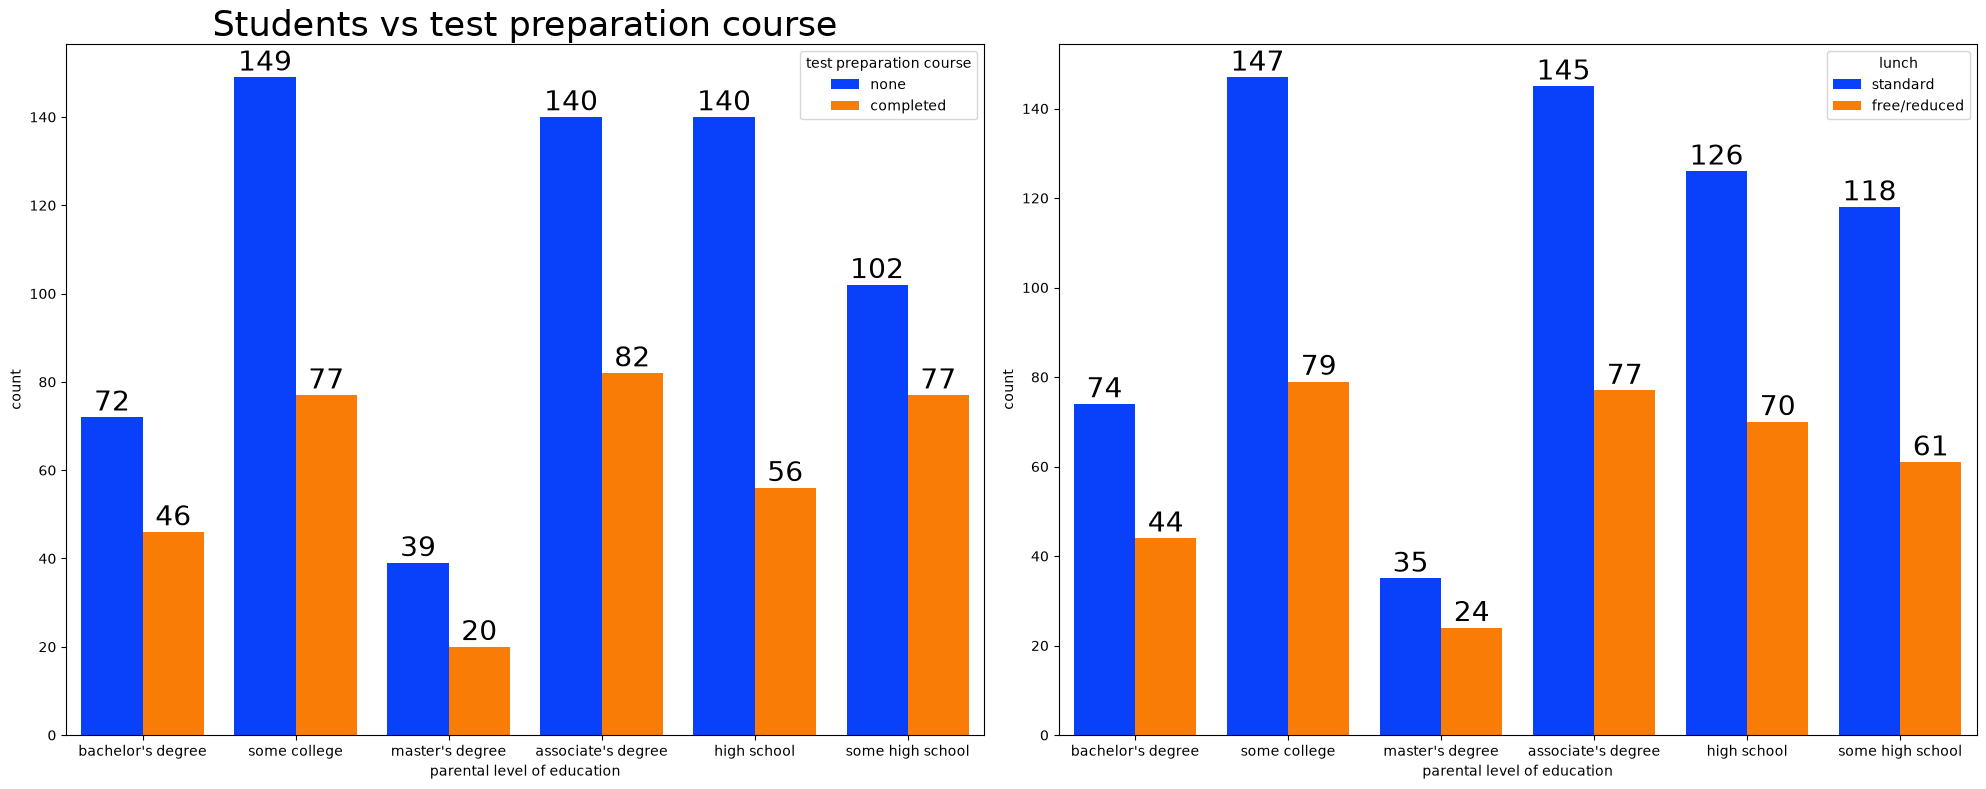

In [70]:
# Create figure with 2 subplots
f, ax = plt.subplots(1, 2, figsize=(20, 8))

# Count plot with Test Preparation Course
sns.countplot(
    x=df['parental level of education'],
    data=df,
    palette='bright',
    hue='test preparation course',
    saturation=0.95,
    ax=ax[0]
)

ax[0].set_title(
    'Students vs test preparation course',
    color='black',
    size=25
)

# Add labels
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)


# Count plot with Lunch Type
sns.countplot(
    x=df['parental level of education'],
    data=df,
    palette='bright',
    hue='lunch',
    saturation=0.95,
    ax=ax[1]
)

# Add labels
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=20)

plt.tight_layout()
plt.show()

## BIVARIATE ANALYSIS ( Is Test preparation course has any impact on student's performance ? )

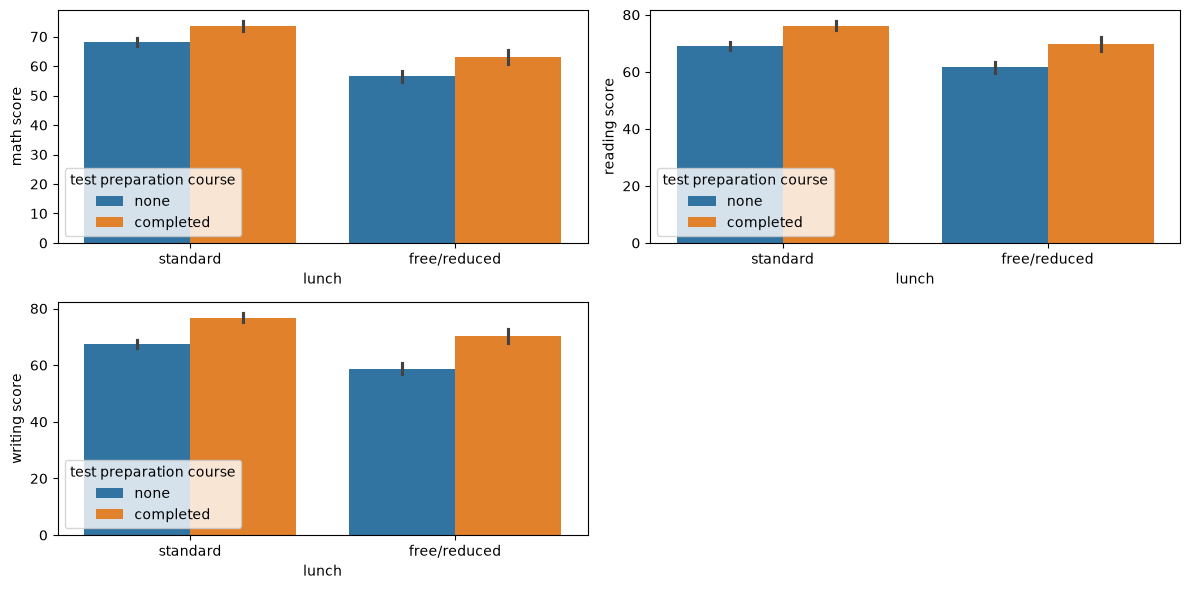

In [71]:
## BIVARIATE ANALYSIS ( Is Test preparation course has any impact on student's performance ? )

plt.figure(figsize=(12,6))

# Math Score
plt.subplot(2,2,1)
sns.barplot(
    x=df['lunch'],
    y=df['math score'],
    hue=df['test preparation course']
)

# Reading Score
plt.subplot(2,2,2)
sns.barplot(
    x=df['lunch'],
    y=df['reading score'],
    hue=df['test preparation course']
)

# Writing Score
plt.subplot(2,2,3)
sns.barplot(
    x=df['lunch'],
    y=df['writing score'],
    hue=df['test preparation course']
)

plt.tight_layout()
plt.show()

### Insights

- Students who completed the test preparation course achieved higher average scores in Mathematics, Reading, and Writing than students who did not complete the course.
- This suggests that completing the test preparation course has a positive impact on students' academic performance across all three subjects.

# 4.4.6 CHECKING OUTLIERS

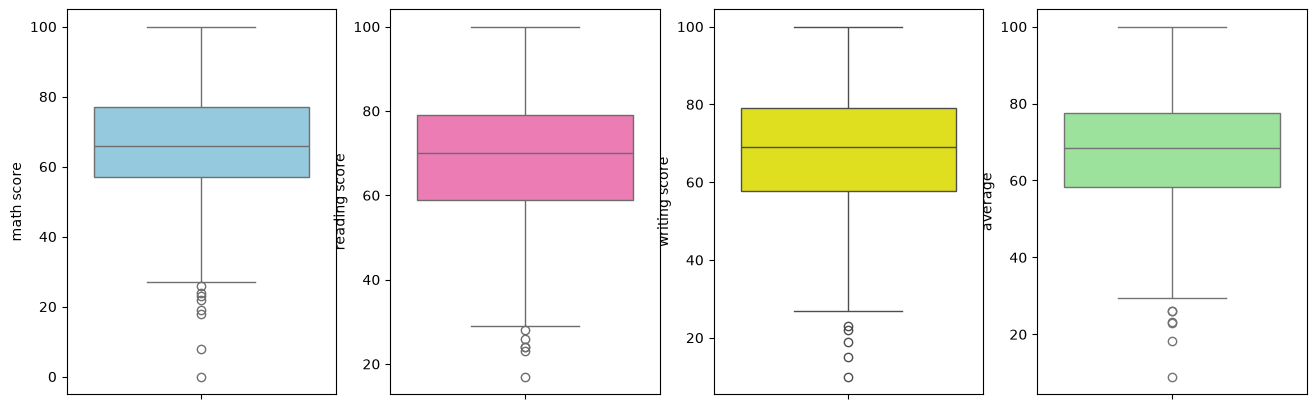

In [72]:
# ==========================================
# 4.4.6 CHECKING OUTLIERS
# ==========================================

plt.subplots(1, 4, figsize=(16, 5))

# Box Plot for Math Score
plt.subplot(141)
sns.boxplot(df['math score'], color='skyblue')

# Box Plot for Reading Score
plt.subplot(142)
sns.boxplot(df['reading score'], color='hotpink')

# Box Plot for Writing Score
plt.subplot(143)
sns.boxplot(df['writing score'], color='yellow')

# Box Plot for Average Score
plt.subplot(144)
sns.boxplot(df['average'], color='lightgreen')

plt.show()

# 5. Conclusions

- Students' performance is influenced by lunch type, race/ethnicity, and parental level of education.
- Female students have a higher pass percentage and generally achieve higher scores than male students.
- Completing the test preparation course positively impacts students' Mathematics, Reading, and Writing scores.
- Students with standard lunch tend to perform better than those with free/reduced lunch.
- Higher parental education levels are generally associated with better student performance.
- The dataset is well-balanced with respect to gender, making it suitable for unbiased analysis.
- Very few outliers were observed in the score distributions, indicating that the dataset is clean and reliable for machine learning.